In [2]:
import pandas as pd
from ultralytics import RTDETR

import cv_folds

In [2]:
all_metrics = []
n_splits = 5
folds_yaml = cv_folds.create_cv_folds(data_yaml='detection_dataset/yolo-test.yaml', n_splits = n_splits)

In [3]:
folds_yaml

['data_0.yaml', 'data_1.yaml', 'data_2.yaml', 'data_3.yaml', 'data_4.yaml']

In [ ]:
for fold, fold_yaml in enumerate(folds_yaml):
    print(f"\n{'='*50}")
    print(f"Training Fold {fold + 1}/5")
    print(f"{'='*50}")

    model = RTDETR('weights/rtdetr-l-finetuned.pt')
    result = model.train(data=fold_yaml,
                        device=0,
                        batch=4,
                        epochs=100,
                        patience=20,
                        lr0 = 1e-5,
                        project='cv_results',
                        freeze=15,
                        warmup_epochs=5,
                        close_mosaic=5,
                        name=f'fold_rt-detr_{fold}',
                        exist_ok=True)
    metrics = model.val(
                    data=f'data_{fold}.yaml',
                    split='val',
                    conf=0.5,
                    iou=0.5,
                    plots=True
                )
    fold_metrics = {
            'fold': fold,
            'map50': metrics.box.map50,
            'map': metrics.box.map,
            'precision': metrics.box.mean_results()[0],
            'recall': metrics.box.mean_results()[1],
        }
    all_metrics.append(fold_metrics)


Training Fold 1/5
New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.13.9 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_0.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=15, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=weights/rtdetr-l-finetuned.pt, momentum=0.937,

C:\Users\diman\Desktop\DIPLOMA 2\.venv\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100       5.1G      1.436     0.4058     0.5351        199        640: 100% ━━━━━━━━━━━━ 13/13 1.1it/s 12.1s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9s/it 3.8s6.8s
                   all         13       1207      0.751      0.631      0.663      0.299

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      2.34G      1.385     0.3258     0.4795        301        640: 0% ──────────── 0/13  0.3s

C:\Users\diman\Desktop\DIPLOMA 2\.venv\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      5.48G      1.244     0.3648     0.4327        109        640: 100% ━━━━━━━━━━━━ 13/13 3.7it/s 3.5s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.8it/s 0.2s0.5s
                   all         13       1207      0.665      0.685      0.618      0.332

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      2.65G      2.065     0.2626      0.829        325        640: 0% ──────────── 0/13  0.3s

...

     63/100      4.55G     0.7231     0.3648     0.1895        789        640: 100% ━━━━━━━━━━━━ 13/13 2.4it/s 5.4s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.2it/s 0.3s0.6s
                   all         12        798      0.563      0.558      0.546      0.302

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     64/100      4.19G     0.6865     0.3574     0.1187        881        640: 0% ──────────── 0/13  0.5s

C:\Users\diman\Desktop\DIPLOMA 2\.venv\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     64/100      6.19G     0.6563     0.3585      0.153        347        640: 100% ━━━━━━━━━━━━ 13/13 2.4it/s 5.4s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.7it/s 0.3s0.5s
                   all         12        798      0.579      0.554      0.561      0.307

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     65/100      3.12G     0.7273     0.3509     0.3114        457        640: 0% ──────────── 0/13  0.5s

C:\Users\diman\Desktop\DIPLOMA 2\.venv\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     65/100      4.41G     0.7401     0.3661     0.2197        836        640: 46% ━━━━━╸────── 6/13 2.3it/s 2.9s<3.1s

In [9]:
all_metrics = [{'map50' : 0.804, 'map' : 0.5}, {'map50' : 0.607, 'map' : 0.338}, {'map50' : 0.681, 'map' : 0.397}, {'map50' : 0.629, 'map' : 0.383}, {'map50' : 0.651, 'map' : 0.403}]

In [10]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df

,map50,map
0,0.804,0.500
1,0.607,0.338
2,0.681,0.397
3,0.629,0.383
4,0.651,0.403


In [13]:
mean_metrics = pd.DataFrame([{'mAP@0.5 (mean)': metrics_df['map50'].mean(),
               'mAP@0.5:0.95 (mean)': metrics_df['map'].mean()}])

mean_metrics

,mAP@0.5 (mean),mAP@0.5:0.95 (mean)
0,0.6744,0.4042


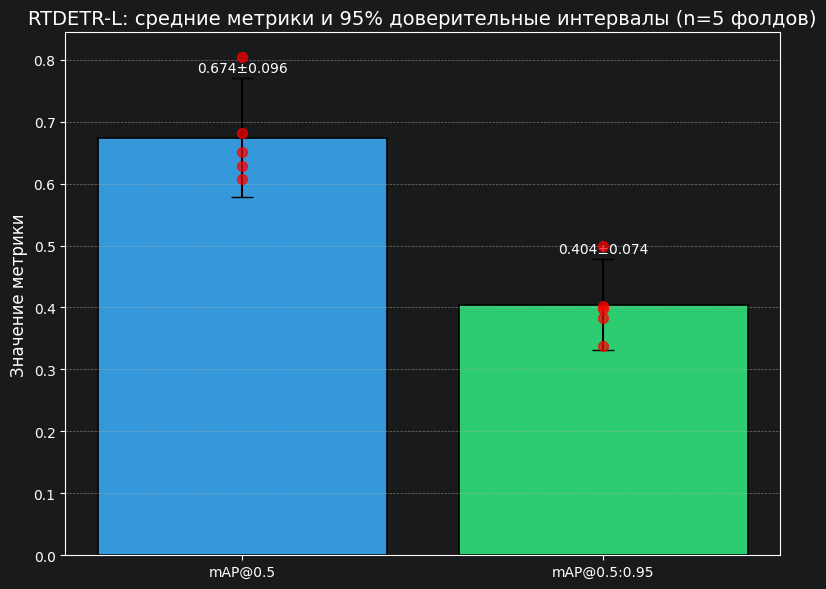

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Функция расчёта среднего и ДИ через t-распределение
def mean_ci(values, conf=0.95):
    mean = np.mean(values)
    se = np.std(values, ddof=1) / np.sqrt(len(values))
    t = stats.t.ppf((1 + conf)/2, len(values)-1)
    margin = t * se
    return mean, margin

# Исходные названия колонок и новые подписи
cols = ['map50', 'map']
labels = ['mAP@0.5', 'mAP@0.5:0.95']

means = []
errors = []
for col in cols:
    m_mean, m_margin = mean_ci(metrics_df[col])
    means.append(m_mean)
    errors.append(m_margin)

# Построение графика
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, means, yerr=errors, capsize=8,
               color=['#3498db', '#2ecc71'],
               edgecolor='black', linewidth=1.2)

# Подписи значений
for bar, mean_val, err_val in zip(bars, means, errors):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + err_val + 0.005,
             f'{mean_val:.3f}±{err_val:.3f}', ha='center', va='bottom', fontsize=10)

# Добавляем точки каждого фолда
for i, col in enumerate(cols):
    y_vals = metrics_df[col]
    plt.scatter([labels[i]] * len(y_vals), y_vals,
                color='red', zorder=5, alpha=0.7, s=50)

plt.ylabel('Значение метрики', fontsize=12)
plt.title('RTDETR-L: средние метрики и 95% доверительные интервалы (n=5 фолдов)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Автоматическая подстройка вертикальных границ (можно оставить)
plt.tight_layout()
plt.show()

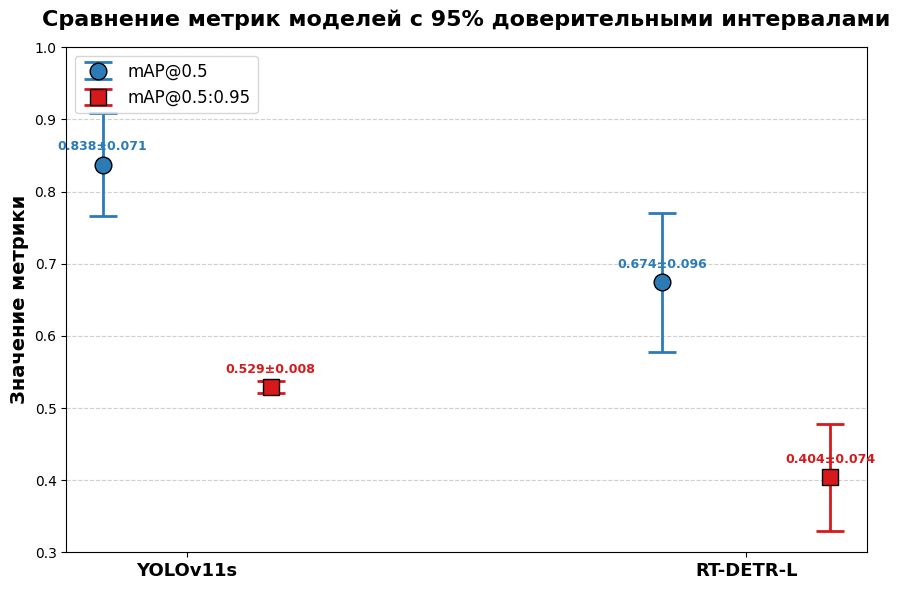

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
models = ['YOLOv11s', 'RT-DETR-L']

map05_means = [0.8375, 0.6740]
map05_errors = [0.0715, 0.0960]

map095_means = [0.5290, 0.4040]
map095_errors = [0.0084, 0.0740]

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(9, 6))

# Точечный график с error bars (стиль как в вашем примере)
ax.errorbar(x - 0.15, map05_means, yerr=map05_errors,
            fmt='o', capsize=10, capthick=2, markersize=12,
            color='#2c7bb6', label='mAP@0.5', elinewidth=2, markeredgecolor='black')

ax.errorbar(x + 0.15, map095_means, yerr=map095_errors,
            fmt='s', capsize=10, capthick=2, markersize=12,
            color='#d7191c', label='mAP@0.5:0.95', elinewidth=2, markeredgecolor='black')

# Оформление
ax.set_ylabel('Значение метрики', fontsize=14, fontweight='semibold')
ax.set_title('Сравнение метрик моделей с 95% доверительными интервалами',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=13, fontweight='semibold')
ax.legend(loc='upper left', fontsize=12, frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0.3, 1.0)

# Подписи значений
for i, (mean, err) in enumerate(zip(map05_means, map05_errors)):
    ax.text(i - 0.15, mean + 0.02, f'{mean:.3f}±{err:.3f}',
            ha='center', fontsize=9, color='#2c7bb6', fontweight='bold')

for i, (mean, err) in enumerate(zip(map095_means, map095_errors)):
    ax.text(i + 0.15, mean + 0.02, f'{mean:.3f}±{err:.3f}',
            ha='center', fontsize=9, color='#d7191c', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_chart_dots.png', dpi=300, bbox_inches='tight')
plt.show()